# Capitulo 2 - Decomposicao Classica de Series Temporais

**Autor:** Rodrigo Santana Ferreira  
**Disciplina:** Series Temporais  

---

Neste notebook vamos aprender a separar uma serie temporal nos seus componentes basicos:
**tendencia**, **sazonalidade** e **residuo (ruido)**.

Usaremos a base de dados **AirPassengers**, que registra o numero de passageiros aereos mensais
entre 1949 e 1960. Ela e um classico para o estudo de series temporais justamente por exibir
tendencia crescente e sazonalidade clara.

---


## 1. Instalacao das dependencias

In [66]:
# Instala as bibliotecas necessarias para o notebook.
# No Google Colab, o '!' indica que o comando sera executado no terminal do sistema.
!pip install pandas numpy matplotlib statsmodels

## 2. Importando as bibliotecas

In [67]:
# Importa todas as bibliotecas que serao usadas ao longo do notebook.
# pandas  -> manipulacao de dados e series temporais
# numpy   -> operacoes matematicas
# matplotlib.pyplot -> criacao de graficos
# statsmodels -> ferramentas estatisticas, incluindo decomposicao de series temporais

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from statsmodels.tsa.seasonal import seasonal_decompose

## 3. Carregando e preparando os dados

In [68]:
# Carrega o dataset AirPassengers diretamente do repositorio do statsmodels.
# Ele contem 144 observacoes mensais (12 anos x 12 meses) do numero de passageiros.
air = get_rdataset("AirPassengers").data

In [69]:
air

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121
...,...,...
139,1960.583333,606
140,1960.666667,508
141,1960.750000,461
142,1960.833333,390


In [70]:
air.index = pd.date_range(start='1949-01', periods=len(air), freq='M')

/tmp/ipykernel_4243/592987349.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  air.index = pd.date_range(start='1949-01', periods=len(air), freq='M')


In [71]:
data = air['value'].astype(float)

In [72]:
print("Dimensoes da serie:", data.shape)

Dimensoes da serie: (144,)


In [73]:
print("Periodo:", data.index[0].strftime('%b/%Y'), "ate", data.index[-1].strftime('%b/%Y'))

Periodo: Jan/1949 ate Dec/1960


In [74]:
print(data.head(12))

1949-01-31    112.0
1949-02-28    118.0
1949-03-31    132.0
1949-04-30    129.0
1949-05-31    121.0
1949-06-30    135.0
1949-07-31    148.0
1949-08-31    148.0
1949-09-30    136.0
1949-10-31    119.0
1949-11-30    104.0
1949-12-31    118.0
Freq: ME, Name: value, dtype: float64


## 4. Visualizando a serie original

Antes de decompor, e importante observar a serie completa. Procure responder:
- A serie sobe ou desce ao longo do tempo? (tendencia)
- Existe algum padrao que se repete todo ano? (sazonalidade)
- Os picos ficam maiores com o tempo? (isso indica modelo multiplicativo)


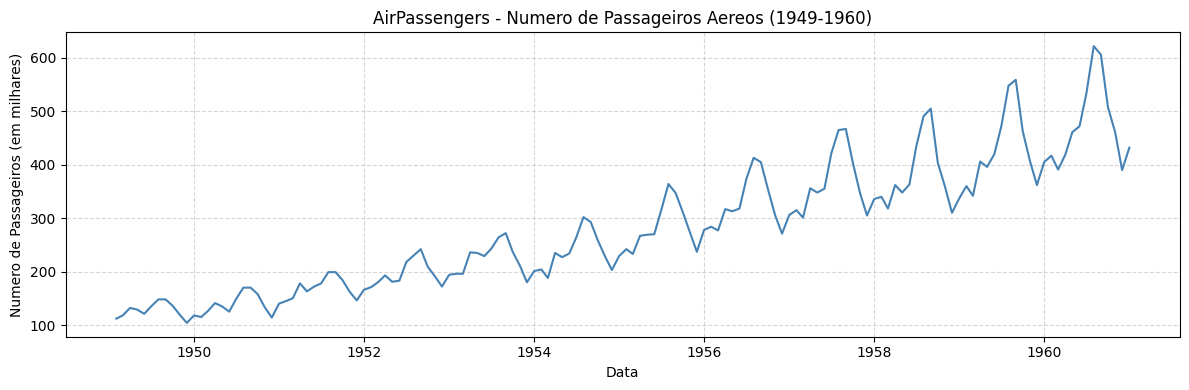

In [75]:
# Plota a serie temporal original para uma primeira inspecao visual.
# Observar o grafico e sempre o primeiro passo em qualquer analise de serie temporal.
plt.figure(figsize=(12, 4))
plt.plot(data, color='steelblue', linewidth=1.5)
plt.title('AirPassengers - Numero de Passageiros Aereos (1949-1960)')
plt.xlabel('Data')
plt.ylabel('Numero de Passageiros (em milhares)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Extraindo a tendencia com medias moveis

A **tendencia** e o comportamento de longo prazo da serie. Para extraia-la, usamos a
**media movel centrada de 12 meses**.

**Como funciona:** para cada ponto no tempo, calculamos a media dos 6 meses anteriores
e dos 6 meses seguintes. Isso suaviza as oscilacoes sazonais e revela so a direcao geral.

> **Por que 12 meses?** Porque nossos dados sao mensais e a sazonalidade se repete
> a cada 12 meses. Usar uma janela igual ao periodo sazonal cancela o efeito da sazonalidade.


In [76]:
# Calcula a media movel centrada com janela de 12 periodos.
# center=True garante que a media e calculada simetricamente em torno de cada ponto,
# o que produz uma tendencia mais precisa do que usar so valores passados.
tendencia_mm = data.rolling(window=12, center=True).mean()

In [77]:
print("Media Movel de 12 meses (primeiros 20 valores):")
print(tendencia_mm.head(20))

Media Movel de 12 meses (primeiros 20 valores):
1949-01-31           NaN
1949-02-28           NaN
1949-03-31           NaN
1949-04-30           NaN
1949-05-31           NaN
1949-06-30           NaN
1949-07-31    126.666667
1949-08-31    126.916667
1949-09-30    127.583333
1949-10-31    128.333333
1949-11-30    128.833333
1949-12-31    129.166667
1950-01-31    130.333333
1950-02-28    132.166667
1950-03-31    134.000000
1950-04-30    135.833333
1950-05-31    137.000000
1950-06-30    137.833333
1950-07-31    139.666667
1950-08-31    142.166667
Freq: ME, Name: value, dtype: float64


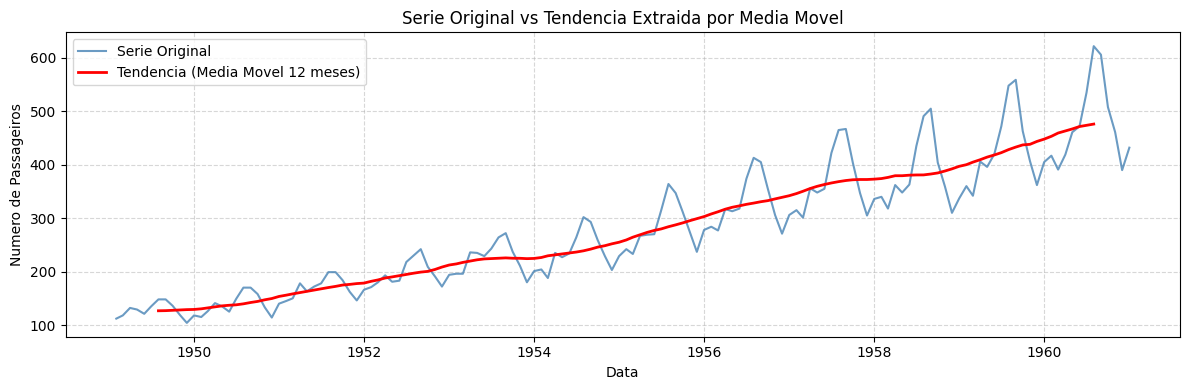

In [78]:
# Plota a serie original junto com a tendencia extraida pela media movel.
# A linha vermelha representa o comportamento de longo prazo, sem as oscilacoes sazonais.
plt.figure(figsize=(12, 4))
plt.plot(data, label='Serie Original', color='steelblue', alpha=0.8)
plt.plot(tendencia_mm, label='Tendencia (Media Movel 12 meses)', color='red', linewidth=2)
plt.title('Serie Original vs Tendencia Extraida por Media Movel')
plt.xlabel('Data')
plt.ylabel('Numero de Passageiros')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Calculando a sazonalidade manualmente

Com a tendencia em maos, podemos isolar o componente sazonal. A logica e:

- **Modelo aditivo:** sazonalidade = serie - tendencia
- **Modelo multiplicativo:** sazonalidade = serie / tendencia

Depois, calculamos a **media de cada mes** ao longo de todos os anos.
Isso nos da o "perfil sazonal" tipico de cada mes.


In [79]:
# No modelo multiplicativo, dividimos a serie pela tendencia.
# O resultado e uma serie que contem apenas sazonalidade e ruido, sem a tendencia.
# Valores acima de 1.0 indicam meses com mais passageiros que a tendencia esperaria.
# Valores abaixo de 1.0 indicam meses mais fracos.
serie_sem_tendencia = data / tendencia_mm

In [80]:
print("Serie sem tendencia (primeiros 20 valores):")
print(serie_sem_tendencia.head(20))

Serie sem tendencia (primeiros 20 valores):
1949-01-31         NaN
1949-02-28         NaN
1949-03-31         NaN
1949-04-30         NaN
1949-05-31         NaN
1949-06-30         NaN
1949-07-31    1.168421
1949-08-31    1.166120
1949-09-30    1.065970
1949-10-31    0.927273
1949-11-30    0.807245
1949-12-31    0.913548
1950-01-31    0.882353
1950-02-28    0.953342
1950-03-31    1.052239
1950-04-30    0.993865
1950-05-31    0.912409
1950-06-30    1.081016
1950-07-31    1.217184
1950-08-31    1.195780
Freq: ME, Name: value, dtype: float64


In [81]:
# Agrupa os valores pela posicao dentro do ano (mes 1, 2, ..., 12)
# e calcula a media de cada mes em todos os anos.
# Isso revela o padrao sazonal medio ao longo dos 12 anos observados.
indice_sazonal = serie_sem_tendencia.groupby(serie_sem_tendencia.index.month).mean()

print("Indice Sazonal por Mes (media historica):")
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
for i, (mes, val) in enumerate(zip(meses, indice_sazonal)):
    print(f"  {mes}: {val:.4f}")

Indice Sazonal por Mes (media historica):
  Jan: 0.9147
  Fev: 0.8879
  Mar: 1.0109
  Abr: 0.9788
  Mai: 0.9836
  Jun: 1.1157
  Jul: 1.2364
  Ago: 1.2227
  Set: 1.0634
  Out: 0.9245
  Nov: 0.8038
  Dez: 0.9025


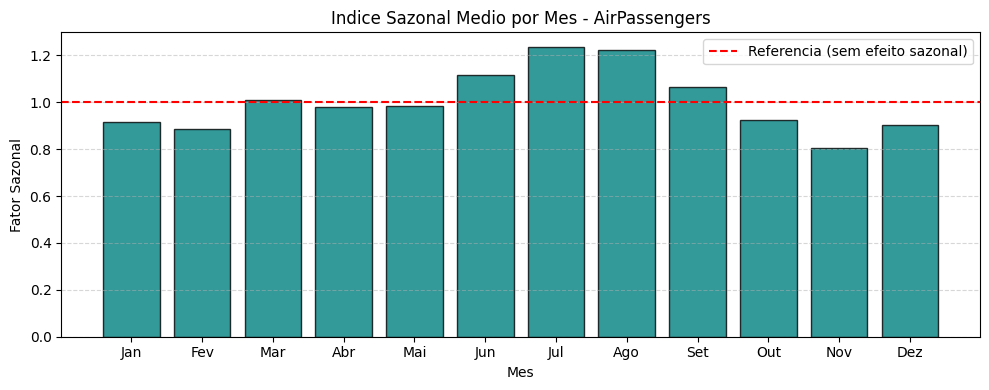

In [82]:
# Plota o indice sazonal para visualizar quais meses sao tipicamente mais fortes ou mais fracos.
# A linha tracejada em 1.0 e a referencia: acima = acima da media, abaixo = abaixo da media.
plt.figure(figsize=(10, 4))
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
plt.bar(meses, indice_sazonal.values, color='teal', edgecolor='black', alpha=0.8)
plt.axhline(y=1.0, color='red', linestyle='--', label='Referencia (sem efeito sazonal)')
plt.title('Indice Sazonal Medio por Mes - AirPassengers')
plt.xlabel('Mes')
plt.ylabel('Fator Sazonal')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Modelo Aditivo

No **modelo aditivo**, assumimos que os componentes se somam:

> **Observado = Tendencia + Sazonalidade + Residuo**

Esse modelo e adequado quando a amplitude das oscilacoes sazonais
**nao muda com o tempo** - ou seja, os picos e vales tem sempre a mesma altura.


In [83]:
# Realiza a decomposicao aditiva com seasonal_decompose.
# model='additive' assume que os componentes sao somados.
# period=12 indica que o ciclo sazonal se completa a cada 12 meses.
decomp_aditivo = seasonal_decompose(data, model='additive', period=12)

In [84]:
print("Componentes do modelo aditivo (primeiros 15 valores de cada):")
print()
print("Tendencia:")
print(decomp_aditivo.trend.dropna().head(15))

Componentes do modelo aditivo (primeiros 15 valores de cada):

Tendencia:
1949-07-31    126.791667
1949-08-31    127.250000
1949-09-30    127.958333
1949-10-31    128.583333
1949-11-30    129.000000
1949-12-31    129.750000
1950-01-31    131.250000
1950-02-28    133.083333
1950-03-31    134.916667
1950-04-30    136.416667
1950-05-31    137.416667
1950-06-30    138.750000
1950-07-31    140.916667
1950-08-31    143.166667
1950-09-30    145.708333
Freq: ME, Name: trend, dtype: float64


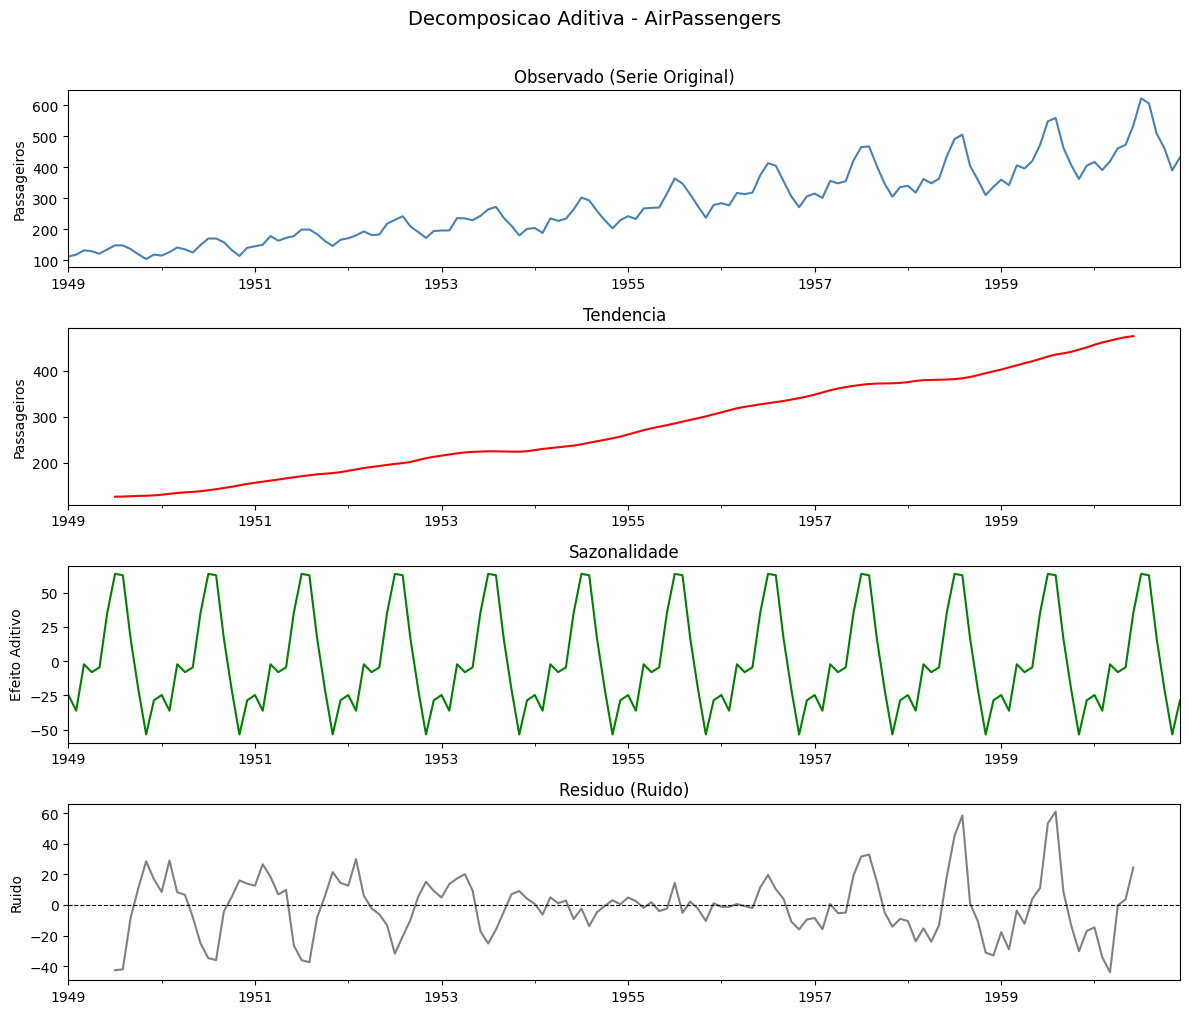

In [85]:
# Plota a decomposicao aditiva em 4 paineis: original, tendencia, sazonalidade e residuo.
# Cada painel revela uma parte diferente do comportamento da serie.
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

decomp_aditivo.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observado (Serie Original)')
axes[0].set_ylabel('Passageiros')

decomp_aditivo.trend.plot(ax=axes[1], color='red')
axes[1].set_title('Tendencia')
axes[1].set_ylabel('Passageiros')

decomp_aditivo.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Sazonalidade')
axes[2].set_ylabel('Efeito Aditivo')

decomp_aditivo.resid.plot(ax=axes[3], color='gray')
axes[3].set_title('Residuo (Ruido)')
axes[3].set_ylabel('Ruido')
axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Decomposicao Aditiva - AirPassengers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 8. Modelo Multiplicativo

No **modelo multiplicativo**, os componentes se multiplicam:

> **Observado = Tendencia x Sazonalidade x Residuo**

Esse modelo e mais adequado quando a amplitude sazonal **cresce junto com a tendencia**,
ou seja, os picos ficam cada vez mais altos com o passar do tempo.

Olhando o grafico do AirPassengers, percebemos que os picos de verao ficam
progressivamente maiores - isso e um sinal classico de que o modelo multiplicativo
e mais apropriado para esses dados.


In [86]:
# Realiza a decomposicao multiplicativa.
# model='multiplicative' e indicado quando a variabilidade sazonal aumenta com o nivel da serie.
# Nesse modelo, os valores de sazonalidade sao fatores (multiplicadores), nao diferenca.
decomp_mult = seasonal_decompose(data, model='multiplicative', period=12)

In [87]:
print("Componente Sazonal do modelo multiplicativo (primeiro ano completo):")
print(decomp_mult.seasonal.head(12))
print()
print("Valores acima de 1.0 = meses com mais passageiros que o esperado pela tendencia")
print("Valores abaixo de 1.0 = meses com menos passageiros que o esperado")

Componente Sazonal do modelo multiplicativo (primeiro ano completo):
1949-01-31    0.910230
1949-02-28    0.883625
1949-03-31    1.007366
1949-04-30    0.975906
1949-05-31    0.981378
1949-06-30    1.112776
1949-07-31    1.226556
1949-08-31    1.219911
1949-09-30    1.060492
1949-10-31    0.921757
1949-11-30    0.801178
1949-12-31    0.898824
Freq: ME, Name: seasonal, dtype: float64

Valores acima de 1.0 = meses com mais passageiros que o esperado pela tendencia
Valores abaixo de 1.0 = meses com menos passageiros que o esperado


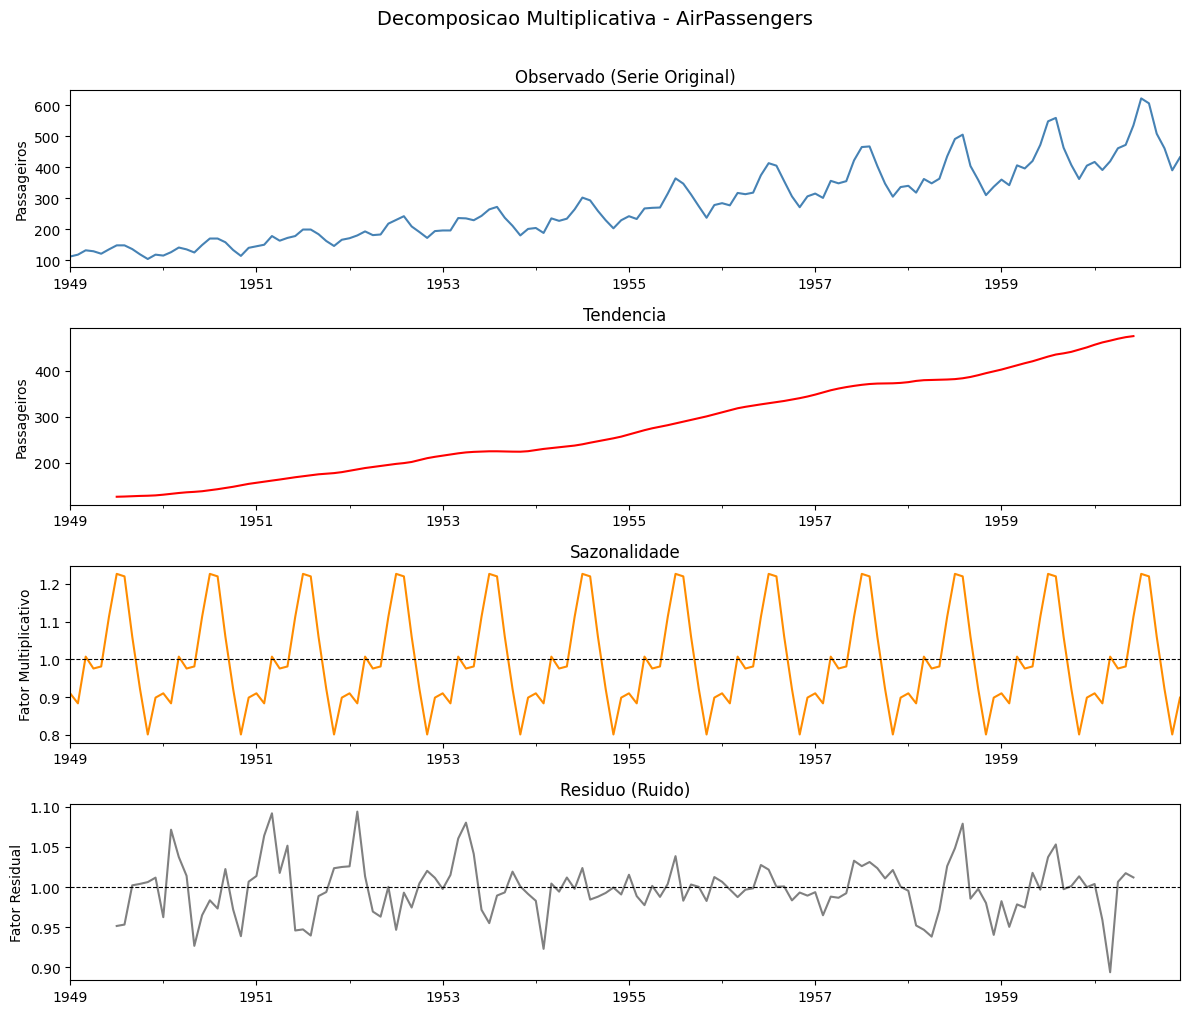

In [88]:
# Plota a decomposicao multiplicativa nos mesmos 4 paineis.
# Compare com o grafico anterior: o comportamento da sazonalidade e do residuo mudam.
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

decomp_mult.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observado (Serie Original)')
axes[0].set_ylabel('Passageiros')

decomp_mult.trend.plot(ax=axes[1], color='red')
axes[1].set_title('Tendencia')
axes[1].set_ylabel('Passageiros')

decomp_mult.seasonal.plot(ax=axes[2], color='darkorange')
axes[2].set_title('Sazonalidade')
axes[2].set_ylabel('Fator Multiplicativo')
axes[2].axhline(1.0, color='black', linewidth=0.8, linestyle='--')

decomp_mult.resid.plot(ax=axes[3], color='gray')
axes[3].set_title('Residuo (Ruido)')
axes[3].set_ylabel('Fator Residual')
axes[3].axhline(1.0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Decomposicao Multiplicativa - AirPassengers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 9. Comparando os dois modelos lado a lado

Uma forma pratica de escolher entre aditivo e multiplicativo e comparar
os **residuos** dos dois modelos. O modelo melhor ajustado tende a produzir
residuos menores e sem padrao sistematico.


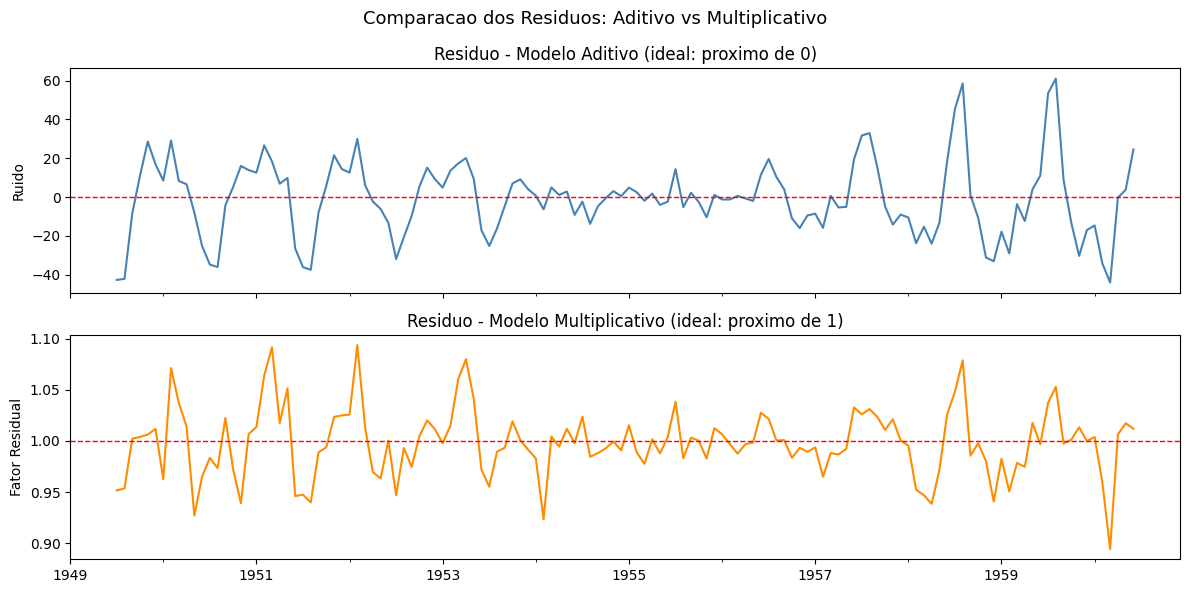

In [89]:
# Compara os residuos dos dois modelos em um unico grafico.
# No modelo aditivo, residuos proximos de 0 indicam bom ajuste.
# No modelo multiplicativo, residuos proximos de 1 indicam bom ajuste.
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

decomp_aditivo.resid.plot(ax=axes[0], color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuo - Modelo Aditivo (ideal: proximo de 0)')
axes[0].set_ylabel('Ruido')

decomp_mult.resid.plot(ax=axes[1], color='darkorange')
axes[1].axhline(1, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Residuo - Modelo Multiplicativo (ideal: proximo de 1)')
axes[1].set_ylabel('Fator Residual')

plt.suptitle('Comparacao dos Residuos: Aditivo vs Multiplicativo', fontsize=13)
plt.tight_layout()
plt.show()

In [90]:
# Calcula a variancia dos residuos de cada modelo para comparacao numerica.
# Menor variancia indica que o modelo capturou melhor a estrutura da serie.
var_aditivo = decomp_aditivo.resid.dropna().var()
var_mult = decomp_mult.resid.dropna().var()

In [91]:
print(f"Variancia do residuo - Modelo Aditivo:       {var_aditivo:.4f}")
print(f"Variancia do residuo - Modelo Multiplicativo: {var_mult:.6f}")
print()
print("O modelo com MENOR variancia de residuo se ajusta melhor aos dados.")


Variancia do residuo - Modelo Aditivo:       374.0563
Variancia do residuo - Modelo Multiplicativo: 0.001115

O modelo com MENOR variancia de residuo se ajusta melhor aos dados.


## 10. Transformacao Logaritmica

Existe uma relacao matematica importante entre os dois modelos:

> Aplicar **log** a um modelo multiplicativo transforma ele em um modelo aditivo.

**Por que isso e util?**
- Alguns algoritmos so funcionam com o modelo aditivo.
- A transformacao log estabiliza a variancia da serie (os picos deixam de ficar
  cada vez maiores).
- Facilita a interpretacao em termos percentuais.

Matematicamente: se Observado = Tendencia x Sazonalidade x Residuo  
Entao: log(Observado) = log(Tendencia) + log(Sazonalidade) + log(Residuo)


In [92]:
# Aplica a transformacao logaritmica natural (base e) na serie original.
# np.log() calcula o logaritmo natural de cada valor da serie.
# Observe que os valores ficam menores e a escala muda completamente.
data_log = np.log(data)

In [93]:
print("Serie original (primeiros 12 valores):")
print(data.head(12).values)
print()
print("Serie apos transformacao log (primeiros 12 valores):")
print(data_log.head(12).values.round(4))


Serie original (primeiros 12 valores):
[112. 118. 132. 129. 121. 135. 148. 148. 136. 119. 104. 118.]

Serie apos transformacao log (primeiros 12 valores):
[4.7185 4.7707 4.8828 4.8598 4.7958 4.9053 4.9972 4.9972 4.9127 4.7791
 4.6444 4.7707]


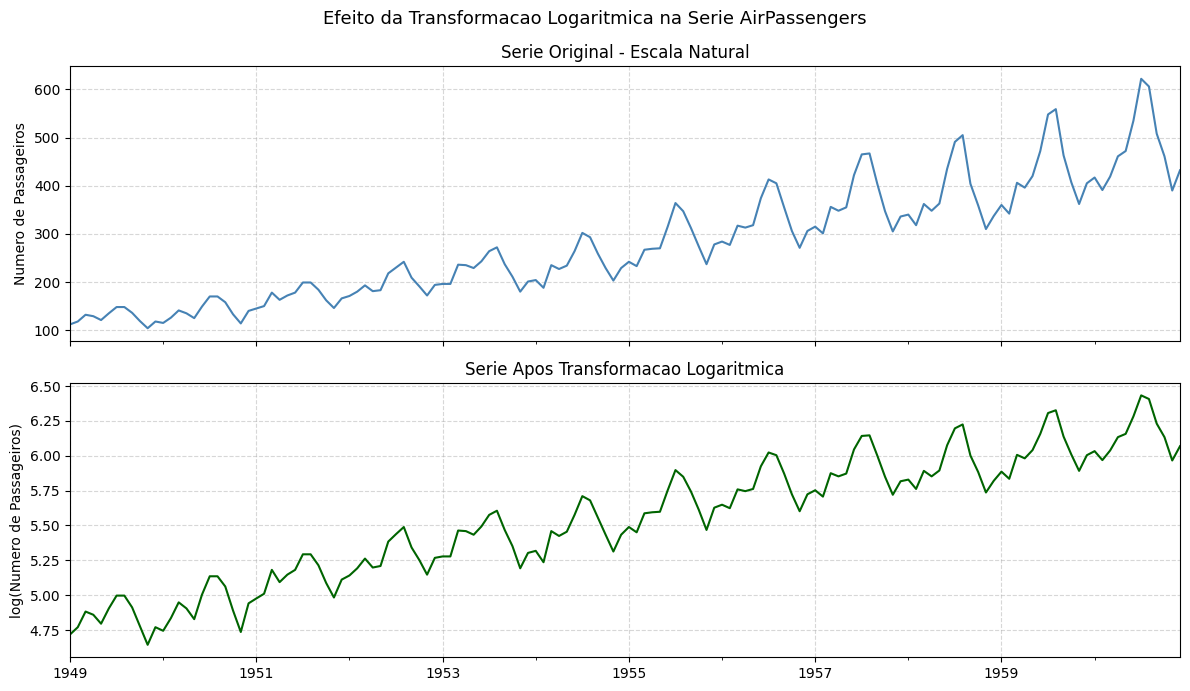

In [94]:
# Plota a serie original e a serie transformada para comparar visualmente.
# Note como a transformacao log 'comprime' os valores altos e suaviza o crescimento da variancia.
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

data.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Serie Original - Escala Natural')
axes[0].set_ylabel('Numero de Passageiros')
axes[0].grid(True, linestyle='--', alpha=0.5)

data_log.plot(ax=axes[1], color='darkgreen')
axes[1].set_title('Serie Apos Transformacao Logaritmica')
axes[1].set_ylabel('log(Numero de Passageiros)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Efeito da Transformacao Logaritmica na Serie AirPassengers', fontsize=13)
plt.tight_layout()
plt.show()

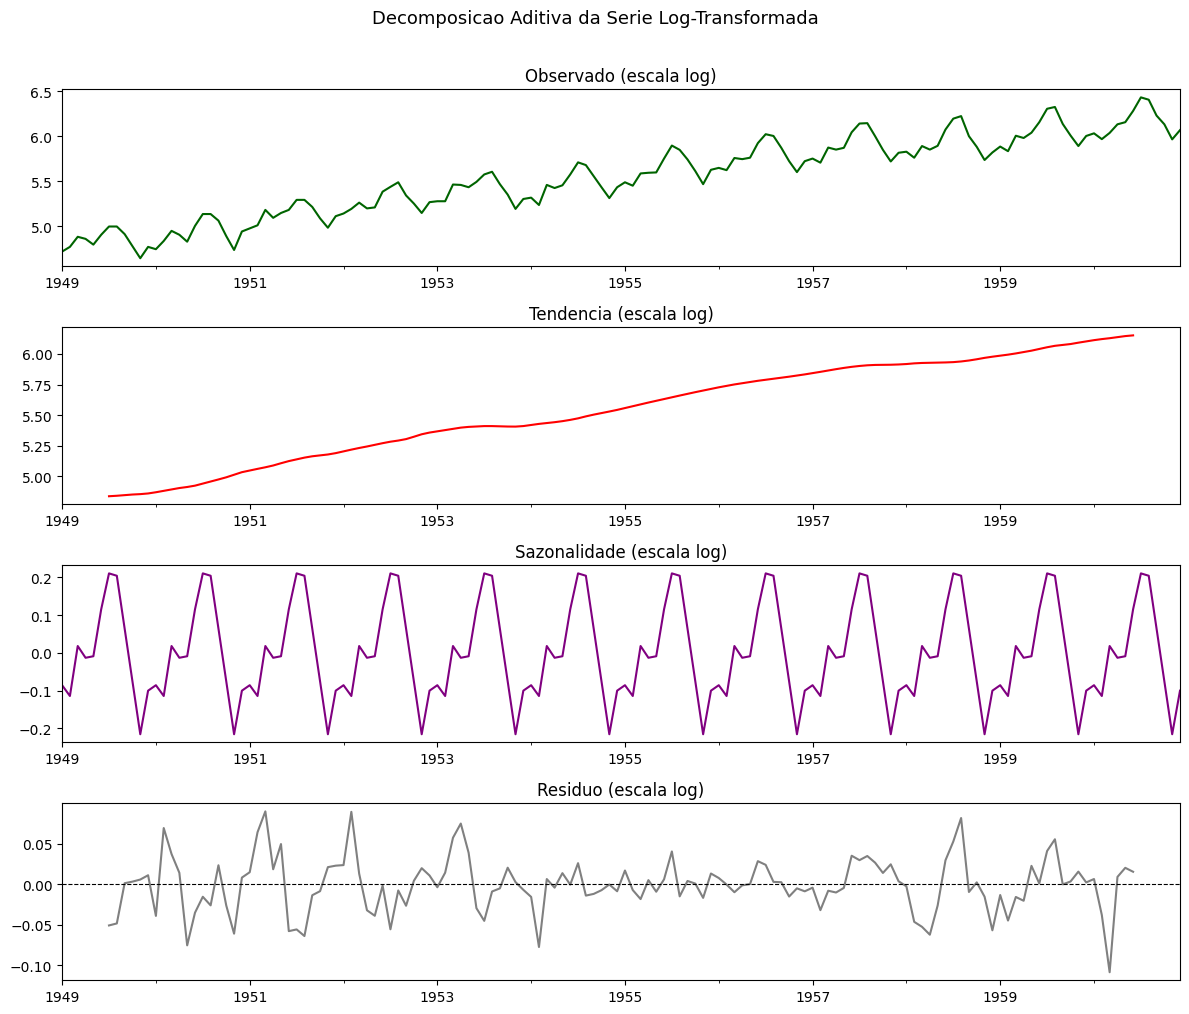

In [95]:
# Aplica a decomposicao aditiva na serie transformada com log.
# Como aplicamos log, podemos usar model='additive' mesmo sendo dados multiplicativos.
# O resultado deve ser equivalente ao modelo multiplicativo na escala original.
decomp_log = seasonal_decompose(data_log, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

decomp_log.observed.plot(ax=axes[0], color='darkgreen')
axes[0].set_title('Observado (escala log)')

decomp_log.trend.plot(ax=axes[1], color='red')
axes[1].set_title('Tendencia (escala log)')

decomp_log.seasonal.plot(ax=axes[2], color='purple')
axes[2].set_title('Sazonalidade (escala log)')

decomp_log.resid.plot(ax=axes[3], color='gray')
axes[3].set_title('Residuo (escala log)')
axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Decomposicao Aditiva da Serie Log-Transformada', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 11. Identificando sazonalidade, tendencia e ciclos nos graficos

### Conceitos

| Componente | Definicao | Como identificar |
|---|---|---|
| **Tendencia** | Movimento de longo prazo | A serie sobe ou desce ao longo de anos |
| **Sazonalidade** | Padrao que se repete em periodo fixo | Mesmos picos/vales todo ano |
| **Ciclo** | Flutuacao de longo prazo sem periodo fixo | Ondulacoes que duram varios anos |
| **Ruido** | Variacao irregular e imprevisivel | O que sobra apos remover os outros |


In [96]:
# Plota a sazonalidade isolada do modelo multiplicativo para um unico ano (2 ciclos completos).
# Isso deixa o padrao sazonal muito mais legivel do que ver 12 anos sobrepostos.
sazonalidade_ano = decomp_mult.seasonal['1949':'1950']

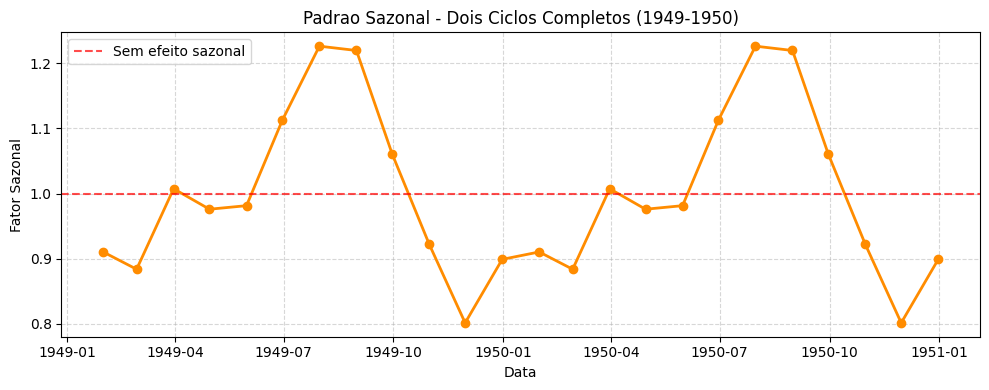

In [97]:
plt.figure(figsize=(10, 4))
plt.plot(sazonalidade_ano, marker='o', color='darkorange', linewidth=2)
plt.title('Padrao Sazonal - Dois Ciclos Completos (1949-1950)')
plt.xlabel('Data')
plt.ylabel('Fator Sazonal')
plt.axhline(1.0, color='red', linestyle='--', alpha=0.7, label='Sem efeito sazonal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 12. Analisando o ruido (residuo)

O residuo e o que sobra da serie depois de remover tendencia e sazonalidade.
Idealmente, ele deve ser **ruido branco**: aleatorio, sem padrao, com media zero
(aditivo) ou proximo de 1 (multiplicativo).

Se o residuo ainda tiver padroes, significa que o modelo de decomposicao nao
capturou toda a estrutura da serie.


In [98]:
# Extrai e limpa os residuos do modelo multiplicativo.
# dropna() remove os valores ausentes nas bordas (inicio e fim),
# que surgem porque a media movel nao pode ser calculada nos extremos.
residuos = decomp_mult.resid.dropna()

In [99]:
print("Estatisticas descritivas do residuo (modelo multiplicativo):")
print(residuos.describe().round(4))
print()
print("Residuo ideal: media proximo de 1.0 e desvio padrao pequeno")


Estatisticas descritivas do residuo (modelo multiplicativo):
count    132.0000
mean       0.9982
std        0.0334
min        0.8941
25%        0.9829
50%        0.9982
75%        1.0152
max        1.0940
Name: resid, dtype: float64

Residuo ideal: media proximo de 1.0 e desvio padrao pequeno


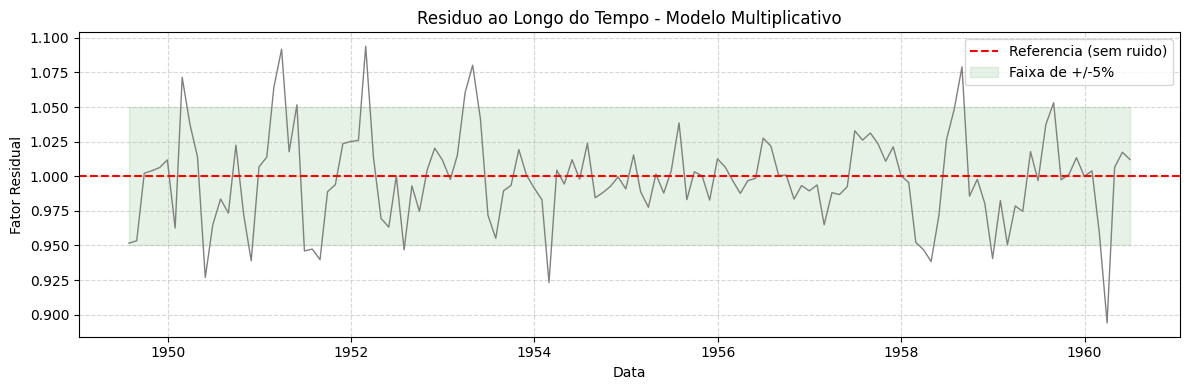

In [100]:
# Plota o residuo ao longo do tempo para verificar se existe algum padrao sistematico.
# Pontos muito distantes da linha de referencia (1.0) indicam anomalias ou eventos incomuns.
plt.figure(figsize=(12, 4))
plt.plot(residuos, color='gray', linewidth=1)
plt.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Referencia (sem ruido)')
plt.fill_between(residuos.index, 0.95, 1.05, alpha=0.1, color='green', label='Faixa de +/-5%')
plt.title('Residuo ao Longo do Tempo - Modelo Multiplicativo')
plt.xlabel('Data')
plt.ylabel('Fator Residual')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

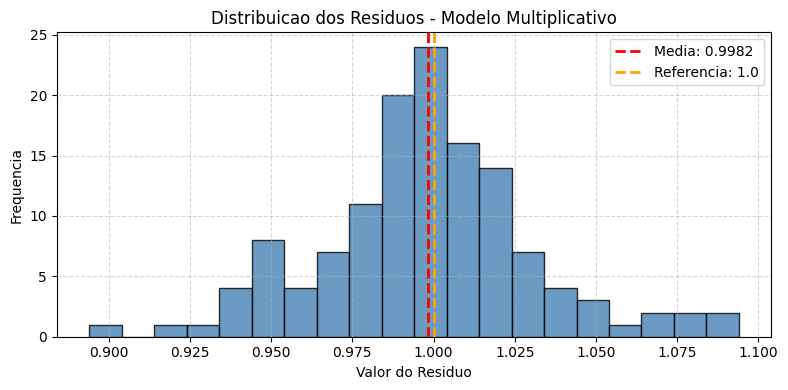

In [101]:
# Plota o histograma dos residuos para verificar se a distribuicao e aproximadamente normal.
# Um ruido branco ideal tende a ter distribuicao normal centrada em 1.0 (modelo multiplicativo).
plt.figure(figsize=(8, 4))
plt.hist(residuos, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(residuos.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {residuos.mean():.4f}')
plt.axvline(1.0, color='orange', linestyle='--', linewidth=2, label='Referencia: 1.0')
plt.title('Distribuicao dos Residuos - Modelo Multiplicativo')
plt.xlabel('Valor do Residuo')
plt.ylabel('Frequencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 13. Resumo dos componentes extraidos

Ao final da decomposicao, podemos reconstruir a serie original a partir dos componentes
e verificar se eles fazem sentido juntos.

**Formula do modelo multiplicativo:**
> Observado = Tendencia x Sazonalidade x Residuo


In [102]:
# Reconstrucao da serie a partir dos componentes decompostos.
# O resultado deve ser muito proximo da serie original (exceto nas bordas onde ha NaN).
serie_reconstruida = (
    decomp_mult.trend *
    decomp_mult.seasonal *
    decomp_mult.resid
).dropna()

# Compara com a serie original
comparacao = pd.DataFrame({
    'Original': data,
    'Reconstruida': serie_reconstruida
}).dropna()

erro_maximo = (comparacao['Original'] - comparacao['Reconstruida']).abs().max()
print(f"Erro maximo entre serie original e reconstruida: {erro_maximo:.6f}")
print("Erro proximo de zero confirma que a decomposicao esta correta.")

Erro maximo entre serie original e reconstruida: 0.000000
Erro proximo de zero confirma que a decomposicao esta correta.


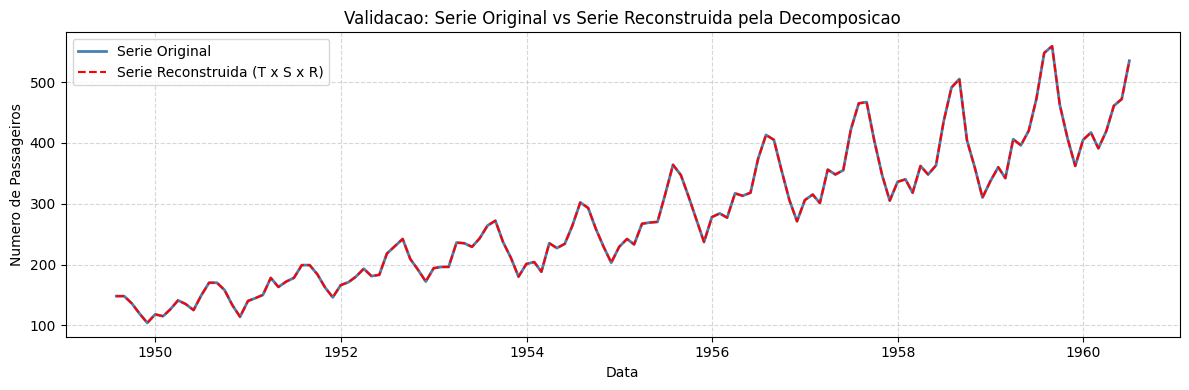

In [103]:
# Plota a serie original ao lado da reconstruida para validacao visual.
# As duas curvas devem ser virtualmente identicas.
plt.figure(figsize=(12, 4))
plt.plot(comparacao['Original'], label='Serie Original', color='steelblue', linewidth=2)
plt.plot(comparacao['Reconstruida'], label='Serie Reconstruida (T x S x R)',
         color='red', linestyle='--', linewidth=1.5)
plt.title('Validacao: Serie Original vs Serie Reconstruida pela Decomposicao')
plt.xlabel('Data')
plt.ylabel('Numero de Passageiros')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Conclusao

Neste notebook aprendemos:

1. **Medias moveis** sao usadas para extrair a tendencia, suavizando as oscilacoes sazonais.
2. A **sazonalidade** pode ser calculada agrupando os dados por periodo (mes, trimestre) e calculando medias.
3. O **residuo** e o que resta apos remover tendencia e sazonalidade.
4. O **modelo aditivo** e adequado quando a sazonalidade tem amplitude constante.
5. O **modelo multiplicativo** e mais adequado quando a amplitude sazonal cresce com a tendencia.
6. A **transformacao logaritmica** converte um modelo multiplicativo em aditivo, facilitando a modelagem.
7. Um bom modelo gera residuos aleatorios, sem padrao e proximos de zero (aditivo) ou de um (multiplicativo).
